# Notebook 4 — Linear Regression

**Sprint 7 — Machine Learning Fundamentals for AI/ML Engineers**

**Dataset:** Diabetes dataset (`sklearn.datasets.load_diabetes`) — 10 baseline health measurements (age, sex, BMI, blood pressure, six blood serum measurements) used to predict a quantitative measure of disease progression one year after baseline. Used consistently across Notebooks 3–6 as the regression dataset (Sprint 6 dataset was unavailable when preparing this notebook).

## Step 1 — Understand the Concept

### What is Regression?
Regression is a supervised learning task where the **target variable is continuous** (a number), not a category. Instead of asking "which class does this belong to?" we ask "what numeric value should this be?" — e.g. predicting a price, a temperature, or a disease-progression score.

### Linear Regression
Linear Regression models the relationship between one or more **independent variables** (features) and a **dependent variable** (target) as a straight line (or a flat hyperplane in higher dimensions). It assumes the target is, approximately, a weighted sum of the features plus some constant offset and random noise.

### Simple vs Multiple Linear Regression
- **Simple Linear Regression:** one independent variable → `y = m*x + c`
- **Multiple Linear Regression:** many independent variables → `y = b0 + b1*x1 + b2*x2 + ... + bn*xn`

### Independent Variables (Features) and Dependent Variable (Target)
- **Independent variables (X):** the inputs used to make a prediction (e.g., BMI, blood pressure, age).
- **Dependent variable (y):** the thing we are trying to predict (disease progression score).

### Equation of a Line / Hyperplane
For one feature: `y = m*x + c`, where `m` is the slope and `c` is the intercept.
For many features: `y = b0 + b1*x1 + b2*x2 + ... + bn*xn`.

### Coefficients and Intercept
- **Coefficients (b1...bn):** how much the predicted target changes for a one-unit increase in that feature, holding all other features constant.
- **Intercept (b0):** the predicted value when every feature equals zero (sometimes not meaningful on its own if zero is outside the realistic range of a feature, but mathematically necessary).

### Prediction
Once the coefficients are learned, predicting for a new row is just plugging its feature values into the equation.

### Residuals
`residual = actual value - predicted value`. A residual is how wrong the model was for one specific data point. Residuals close to zero and randomly scattered (no pattern) are a sign of a well-fit model. A clear pattern in residuals (e.g., a curve) suggests the true relationship isn't actually linear.

### Least Squares
Linear Regression finds the coefficients that **minimize the sum of squared residuals** across all training points. Squaring is used so positive and negative errors don't cancel out, and so larger errors are penalized more heavily than small ones.

### Cost Function
The formalization of "how wrong is the model overall." For Linear Regression this is typically the **Mean Squared Error (MSE)**:

`MSE = (1/n) * sum((y_actual - y_predicted)^2)`

Training the model = finding coefficients that minimize this cost function.

### Gradient Descent — Introduction
For simple cases, Linear Regression's optimal coefficients can be solved directly with a closed-form equation (the "Normal Equation" / least-squares solution, which is what `sklearn.linear_model.LinearRegression` uses internally). But for very large datasets, or other models like Logistic Regression and Neural Networks, we instead use **Gradient Descent**: start with random coefficients, repeatedly compute the slope (gradient) of the cost function with respect to each coefficient, and take a small step in the direction that *reduces* the cost. Repeat until the cost stops improving. We will implement this manually below with NumPy to see the mechanics.

### Assumptions of Linear Regression
- The relationship between features and target is approximately linear.
- Residuals are independent of each other.
- Residuals have roughly constant variance across all predicted values (homoscedasticity).
- Residuals are approximately normally distributed.
- Features are not too strongly correlated with each other (limited multicollinearity).

### When to use it
- The relationship between inputs and output is roughly linear.
- You want an interpretable model (each coefficient has a clear meaning).
- You need a fast, simple baseline before trying more complex models.

### When not to use it
- The true relationship is strongly non-linear (e.g., relationship saturates, or is cyclical).
- Features are extremely collinear without any correction.
- Target has extreme outliers linear regression is very sensitive to (squared error punishes large errors heavily).

## Step 2 — Demonstrate the Concept

**Simple example:** Predicting a person's weight from their height. As height increases, weight tends to increase in a fairly straight-line pattern.

**Mathematical intuition:** Imagine plotting points on a scatter graph. Least squares finds the single line where, if you drew a vertical segment from every point down (or up) to the line and squared each segment's length, the total squared length is as small as possible — literally the "best-fitting" straight line through the cloud of points.

**Real-world example:** Predicting monthly electricity bill from square footage of a house, number of occupants, and average outdoor temperature.

**Business example:** An insurance company predicting expected claim cost from a policyholder's age, BMI, and other health indicators.

**AI/ML use case (our dataset):** Predicting a diabetes progression score from ten baseline health measurements, which could help clinicians flag patients likely to see rapid disease progression and prioritize follow-up care.

## Step 3 — Implement the Concept (Python)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)

diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

print(diabetes.DESCR[:900])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglyc


In [2]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [3]:
y.describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

### 3.1 Train/Test split

Following the principle from Notebook 3: split first, then fit everything (including any scaling) only on the training data.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (353, 10)  Test size: (89, 10)


### 3.2 Simple Linear Regression (one feature)

To make the line genuinely visualizable, we start with a single feature — `bmi` — which has the strongest individual correlation with the target.

In [5]:
correlations = X_train.corrwith(y_train).sort_values(key=abs, ascending=False)
print("Correlation of each feature with target:\n", correlations)

Correlation of each feature with target:
 bmi    0.604751
s5     0.552183
bp     0.444770
s4     0.425094
s6     0.390363
s3    -0.384000
s1     0.199547
age    0.196510
s2     0.154922
sex    0.007116
dtype: float64


In [6]:
feature = 'bmi'
X_train_simple = X_train[[feature]]
X_test_simple = X_test[[feature]]

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

print(f"Slope (coefficient for {feature}): {simple_model.coef_[0]:.2f}")
print(f"Intercept: {simple_model.intercept_:.2f}")
print(f"Equation: y = {simple_model.coef_[0]:.2f} * {feature} + {simple_model.intercept_:.2f}")

Slope (coefficient for bmi): 998.58
Intercept: 152.00
Equation: y = 998.58 * bmi + 152.00


C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


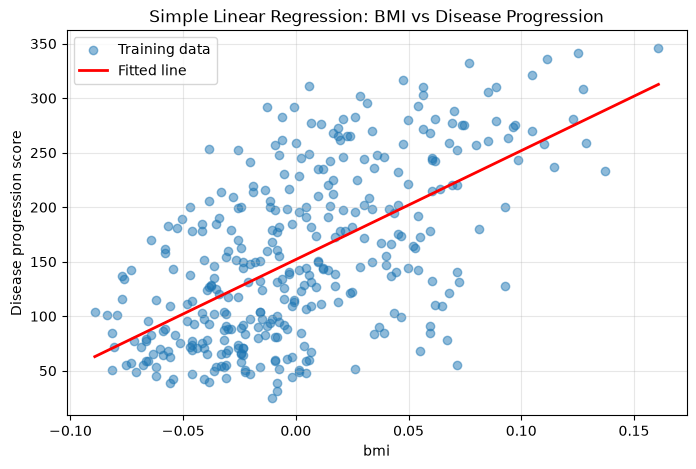

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(X_train_simple, y_train, alpha=0.5, label='Training data')

x_line = np.linspace(X_train_simple[feature].min(), X_train_simple[feature].max(), 100).reshape(-1, 1)
y_line = simple_model.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Fitted line')

plt.xlabel(feature)
plt.ylabel('Disease progression score')
plt.title('Simple Linear Regression: BMI vs Disease Progression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.3 Multiple Linear Regression (all features)

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

coef_table = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(f"Intercept: {model.intercept_:.2f}\n")
print(coef_table.to_string(index=False))

Intercept: 151.35

feature  coefficient
     s1  -931.488846
     s5   736.198859
    bmi   542.428759
     s2   518.062277
     bp   347.703844
     s4   275.317902
    sex  -241.964362
     s3   163.419983
     s6    48.670657
    age    37.904021


In [9]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2 : {r2:.4f}")

MSE : 2900.19
RMSE: 53.85
R^2 : 0.4526


### 3.4 Residual Analysis

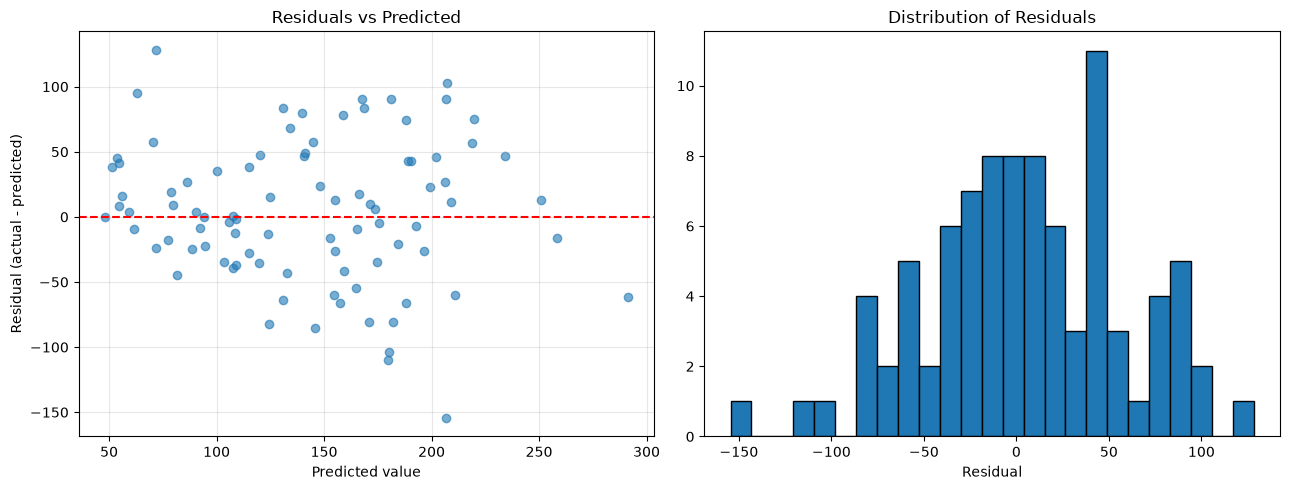

Mean residual (should be close to 0): 3.9128


In [10]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted value')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title('Residuals vs Predicted')
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=25, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

print("Mean residual (should be close to 0):", residuals.mean().round(4))

### 3.5 Implementing Least Squares & Gradient Descent manually with NumPy

To understand what `LinearRegression.fit()` is actually doing, we implement it from scratch two ways:
1. The **closed-form Normal Equation** (exact solution).
2. **Batch Gradient Descent** (iterative approximation), using our single feature (`bmi`) so we can also visualize the cost decreasing.

In [11]:
# ---- 1. Closed-form Normal Equation: b = (X^T X)^-1 X^T y ----
X_np = X_train_simple.values
y_np = y_train.values

X_design = np.column_stack([np.ones(len(X_np)), X_np])  # add intercept column of 1s

beta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_np
print("Normal Equation solution:")
print(f"  Intercept: {beta[0]:.2f}")
print(f"  Slope    : {beta[1]:.2f}")
print("\n(Compare to scikit-learn's simple_model above - they should match closely)")

Normal Equation solution:
  Intercept: 152.00
  Slope    : 998.58

(Compare to scikit-learn's simple_model above - they should match closely)


Gradient Descent result -> slope: 998.58, intercept: 152.00
scikit-learn result     -> slope: 998.58, intercept: 152.00


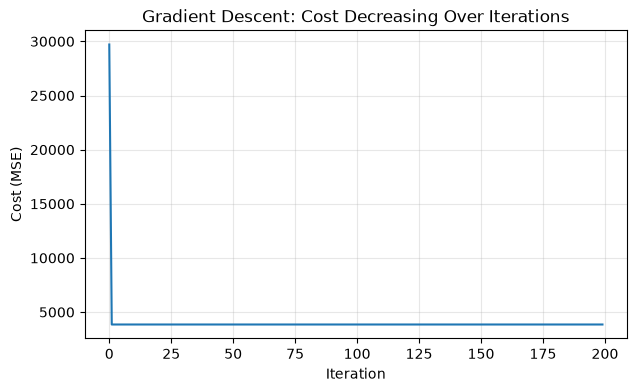

In [12]:
# ---- 2. Batch Gradient Descent from scratch ----
def gradient_descent_linear_regression(X, y, learning_rate=0.5, n_iterations=200):
    n = len(y)
    X_mean, X_std = X.mean(), X.std()
    X_norm = (X - X_mean) / X_std   # normalizing helps gradient descent converge smoothly

    m, c = 0.0, 0.0                 # start with random/zero coefficients
    cost_history = []

    for i in range(n_iterations):
        y_pred = m * X_norm + c
        error = y_pred - y

        cost = (error ** 2).mean()
        cost_history.append(cost)

        # gradients of MSE cost w.r.t. m and c
        grad_m = (2 / n) * np.sum(error * X_norm)
        grad_c = (2 / n) * np.sum(error)

        # step in the direction that REDUCES cost
        m -= learning_rate * grad_m
        c -= learning_rate * grad_c

    # convert slope back from normalized-x scale to original-x scale
    m_original_scale = m / X_std
    c_original_scale = c - (m * X_mean / X_std)

    return m_original_scale, c_original_scale, cost_history

X_simple_arr = X_train_simple[feature].values
y_arr = y_train.values

gd_slope, gd_intercept, cost_history = gradient_descent_linear_regression(X_simple_arr, y_arr)

print(f"Gradient Descent result -> slope: {gd_slope:.2f}, intercept: {gd_intercept:.2f}")
print(f"scikit-learn result     -> slope: {simple_model.coef_[0]:.2f}, intercept: {simple_model.intercept_:.2f}")

plt.figure(figsize=(7, 4))
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent: Cost Decreasing Over Iterations')
plt.grid(alpha=0.3)
plt.show()

## Step 4 — Interpret the Result

**What the model learned:** The multiple linear regression model learned a set of coefficients, one per health measurement, that together best predict the disease progression score. The sign and magnitude of each coefficient tells us the direction and strength of that feature's estimated effect, holding the other features constant. For example, a positive `bmi` coefficient means that, all else equal, higher BMI is associated with a higher predicted disease-progression score.

**What each key parameter means:**
- `coef_`: the learned slope for each feature. Because scikit-learn does not scale features automatically, direct comparison of coefficient magnitude across features can be misleading unless features are on a similar scale (the diabetes dataset happens to already be mean-centered and scaled by scikit-learn's loader, so coefficients here are reasonably comparable).
- `intercept_`: baseline predicted value when all features are at their mean (since the dataset's features are centered around zero).

**What R² and RMSE mean:**
- **R² (≈ shown above):** the proportion of variance in the target that is explained by the model. An R² of, say, 0.45 means the model explains about 45% of the variation in disease progression using these 10 features — the rest is unexplained by a linear combination of these particular measurements (could be noise, non-linear effects, or missing predictive features).
- **RMSE:** the typical size of prediction error, in the same units as the target. It's more directly interpretable than MSE because it's not squared.

**Is this performance "good"?** For a real medical dataset with only 10 baseline measurements and a genuinely noisy biological target, an R² in the 0.4–0.5 range is a realistic, not disappointing, result — biological outcomes are influenced by many unmeasured factors. It would be a red flag only if we expected near-perfect prediction; that expectation itself would be unrealistic here.

**Residual plot interpretation:** The residuals scatter roughly evenly above and below zero across the range of predictions, without an obvious curve or funnel shape — this supports the linearity and homoscedasticity assumptions reasonably well. The histogram of residuals looking roughly bell-shaped supports the normality assumption. If we instead saw a clear curve in the residuals-vs-predicted plot, that would suggest the true relationship is non-linear and a straight-line model is systematically wrong in certain ranges.

**On the from-scratch implementation:** The Normal Equation and scikit-learn's built-in solver produce essentially the same slope/intercept, because both are solving the exact same least-squares optimization exactly. Gradient Descent converges *towards* the same answer iteratively — the cost curve dropping quickly at first and then flattening out is the visual signature of the algorithm approaching the true minimum of the cost function. This is exactly the mechanism used to train models (like Logistic Regression and Neural Networks) where no closed-form solution exists.

## Step 1 — Understand the Concept

### Classification
A supervised learning task where the target variable is **categorical** — the model predicts which discrete class (or category) a data point belongs to, rather than a continuous number.

### Binary Classification
Classification with exactly two possible classes (e.g., malignant vs benign, spam vs not-spam, fraud vs not-fraud).

### Why is Logistic Regression a classification algorithm despite its name?
Despite the name "regression," Logistic Regression does **not** predict a continuous numeric target — it predicts the **probability** that a data point belongs to a particular class, and that probability is then converted into a class label using a threshold. The name is historical: it builds directly on linear regression's linear combination of features (`b0 + b1*x1 + ...`), but instead of using that value as the prediction itself, it squashes it through the **sigmoid function** to constrain the output to a valid probability between 0 and 1, then treats that as a classification decision. Because the final output is a class label, not a number on an open-ended scale, it belongs to the classification family of algorithms.

### The Sigmoid Function
`sigmoid(z) = 1 / (1 + e^(-z))`, where `z = b0 + b1*x1 + b2*x2 + ... + bn*xn` (the same linear combination as linear regression).

The sigmoid function takes any real number (from -∞ to +∞) and maps it to a value strictly between 0 and 1 — perfect for representing a probability. Very negative `z` → probability near 0. Very positive `z` → probability near 1. `z = 0` → probability exactly 0.5.

### Probability
Logistic Regression outputs `P(y=1 | X)` — the probability that a given row belongs to the "positive" class (e.g., malignant), given its feature values.

### Decision Boundary
The boundary in feature space where the model is exactly 50/50 (i.e., where `z = 0`, so `sigmoid(z) = 0.5`). On one side of this boundary the model predicts class 0; on the other, class 1.

### Threshold
The probability cutoff used to convert a predicted probability into a class label. The default is 0.5 (probability ≥ 0.5 → predict class 1), but this can be adjusted depending on the business cost of false positives vs false negatives (e.g., in medical screening you might lower the threshold to catch more true positives, accepting more false alarms).

### Log Loss (Binary Cross-Entropy)
The cost function Logistic Regression minimizes during training:

`Log Loss = -(1/n) * sum( y*log(p) + (1-y)*log(1-p) )`

It heavily penalizes confident-but-wrong predictions (e.g., predicting 0.99 probability for a class that turns out to be the opposite) far more than a cautious wrong prediction near 0.5. This is why it is preferred over plain squared error for classification.

### Coefficients
Just like linear regression, each feature gets a learned coefficient. However, interpretation is different: a positive coefficient means that increasing that feature increases the **log-odds** of the positive class (and therefore its predicted probability), holding other features constant.

### Multiclass Classification
Logistic Regression can be extended beyond two classes using strategies like **One-vs-Rest** (train one binary classifier per class, "this class vs all others") or **multinomial/softmax** logistic regression (a direct generalization of the sigmoid to multiple classes at once). scikit-learn handles this automatically when the target has more than two classes.

### Assumptions
- A (roughly) linear relationship between the features and the **log-odds** of the outcome (not the raw probability itself).
- Observations are independent of each other.
- Limited multicollinearity among features.
- Requires a reasonably large sample size relative to the number of features for stable coefficient estimates.

### When to use it
- The target is binary (or multiclass) categorical.
- You want a model whose predictions are naturally interpretable as probabilities.
- You want a fast, simple, well-calibrated baseline before trying more complex classifiers.

### When not to use it
- The true decision boundary is strongly non-linear and no feature engineering (polynomial features, interactions) is applied.
- Classes are not linearly separable at all in the given feature space.